# 01 — Python para automatizar operaciones de ciberseguridad

**SecOps Hub** usa Python (Flask) como motor de la consola SOC: recibe alertas, enriquece IOCs y orquesta playbooks.

En este notebook verás:
1. Qué operaciones automatiza Python
2. Qué librerías importa el proyecto y para qué
3. Un mapa de módulos `.py` relevantes
4. Una métrica simple del "stack" de dependencias

## 1. Idea central

| Capa | Qué hace Python | Archivos clave |
|------|-----------------|----------------|
| **Ingesta** | Validar API Key, normalizar alerta, deduplicar, crear incidente | `routes/webhooks.py` |
| **Triaje** | Detectar tipo IOC, consultar VT/AbuseIPDB (o simular), veredicto | `ioc_enrichment.py`, `ioc_service.py`, `external_clients.py` |
| **Respuesta** | Ejecutar playbooks (simulado o live) hacia EDR/FW/AD | `playbook_runners.py`, `routes/playbooks.py` |
| **Identidad** | Login JWT, MFA, LDAP, OIDC | `routes/auth.py`, `ldap_auth.py`, `oidc_auth.py` |
| **Observabilidad** | Contadores Prometheus, health | `metrics.py`, `routes/health.py` |

> Python **orquesta**; el SIEM detecta y el EDR/firewall actúan en producción.

## 2. Librerías del `requirements.txt` (backend)

Ejecuta la siguiente celda para cargar y visualizar el inventario de dependencias del proyecto.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Ruta al repo (formacion/ está un nivel bajo la raíz)
ROOT = Path.cwd()
if ROOT.name == "formacion":
    ROOT = ROOT.parent
REQ = ROOT / "backend" / "requirements.txt"

rows = []
for line in REQ.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    pkg = line.split(">=")[0].split("==")[0].split("[")[0].strip()
    rows.append({"paquete": pkg, "especificación": line})

df_deps = pd.DataFrame(rows)
print(f"Dependencias en requirements.txt: {len(df_deps)}")
df_deps

Dependencias en requirements.txt: 16


,paquete,especificación
0,flask,flask>=3.0.0
1,flask-cors,flask-cors>=4.0.0
2,flask-sqlalchemy,flask-sqlalchemy>=3.1.0
3,flask-jwt-extended,flask-jwt-extended>=4.6.0
4,werkzeug,werkzeug>=3.0.0
5,python-dotenv,python-dotenv>=1.0.0
6,reportlab,reportlab>=4.0.0
7,requests,requests>=2.31.0
8,gunicorn,gunicorn>=22.0.0
9,psycopg,psycopg[binary]>=3.1.0


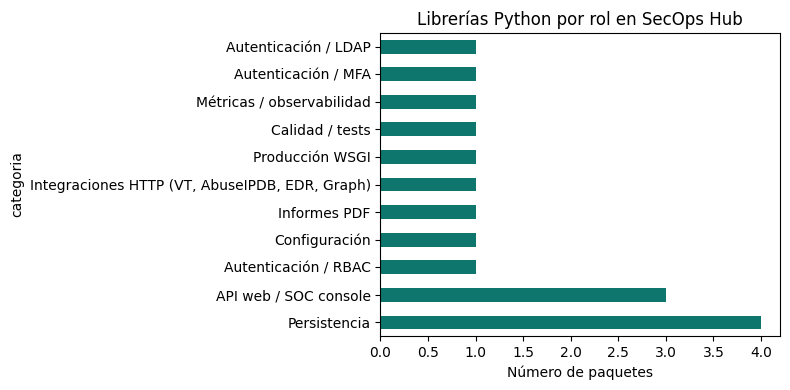

categoria
Persistencia                                      4
API web / SOC console                             3
Autenticación / RBAC                              1
Configuración                                     1
Informes PDF                                      1
Integraciones HTTP (VT, AbuseIPDB, EDR, Graph)    1
Producción WSGI                                   1
Calidad / tests                                   1
Métricas / observabilidad                         1
Autenticación / MFA                               1
Autenticación / LDAP                              1
Name: count, dtype: int64


In [2]:
# Clasificación pedagógica de cada librería
CATEGORIAS = {
    "flask": "API web / SOC console",
    "flask-cors": "API web / SOC console",
    "flask-sqlalchemy": "Persistencia",
    "flask-jwt-extended": "Autenticación / RBAC",
    "werkzeug": "API web / SOC console",
    "python-dotenv": "Configuración",
    "reportlab": "Informes PDF",
    "requests": "Integraciones HTTP (VT, AbuseIPDB, EDR, Graph)",
    "gunicorn": "Producción WSGI",
    "psycopg": "Persistencia",
    "pytest": "Calidad / tests",
    "prometheus-client": "Métricas / observabilidad",
    "pyotp": "Autenticación / MFA",
    "ldap3": "Autenticación / LDAP",
    "alembic": "Persistencia",
    "flask-migrate": "Persistencia",
}

df_deps["categoria"] = df_deps["paquete"].map(
    lambda p: CATEGORIAS.get(p, "Otras")
)
conteo = df_deps["categoria"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
conteo.plot(kind="barh", ax=ax, color="#0f766e")
ax.set_title("Librerías Python por rol en SecOps Hub")
ax.set_xlabel("Número de paquetes")
plt.tight_layout()
plt.show()

print(conteo)

### Detalle de imports en código de operaciones

| Librería (stdlib o pip) | Dónde se usa | Para qué |
|-------------------------|--------------|----------|
| `re` | `ioc_enrichment.py` | Detectar IP / hash / URL |
| `hashlib` | `ioc_enrichment.py` | Simular scores deterministas (demo) |
| `requests` | `external_clients.py`, `playbook_runners.py` | APIs HTTP reales |
| `flask` + blueprints | `routes/*.py` | Endpoints REST |
| `flask_jwt_extended` | auth, decoradores | Tokens y RBAC |
| `datetime` / `timedelta` | webhooks, JWT | Deduplicación y expiración |
| `logging` | webhooks, runners | Auditoría operativa |
| `pyotp` | MFA | TOTP segundo factor |
| `ldap3` | `ldap_auth.py` | Bind directorio |
| `prometheus_client` | `metrics.py` | Contadores/histogramas |
| `reportlab` | `pdf_report.py` | Informe incidente PDF |

## 3. Inventario de módulos `.py` de automatización

La siguiente celda cuenta líneas aproximadas de los servicios SOC (métrica de tamaño del código de automatización).

,módulo,líneas_código,imports,ruta
3,playbook_runners.py,373,5,backend/app/services/playbook_runners.py
7,playbooks.py,198,10,backend/app/routes/playbooks.py
6,webhooks.py,142,7,backend/app/routes/webhooks.py
8,iocs.py,96,8,backend/app/routes/iocs.py
2,external_clients.py,94,5,backend/app/services/external_clients.py
4,kev_sync.py,79,6,backend/app/services/kev_sync.py
1,ioc_service.py,69,3,backend/app/services/ioc_service.py
0,ioc_enrichment.py,42,2,backend/app/services/ioc_enrichment.py
5,metrics.py,35,3,backend/app/services/metrics.py


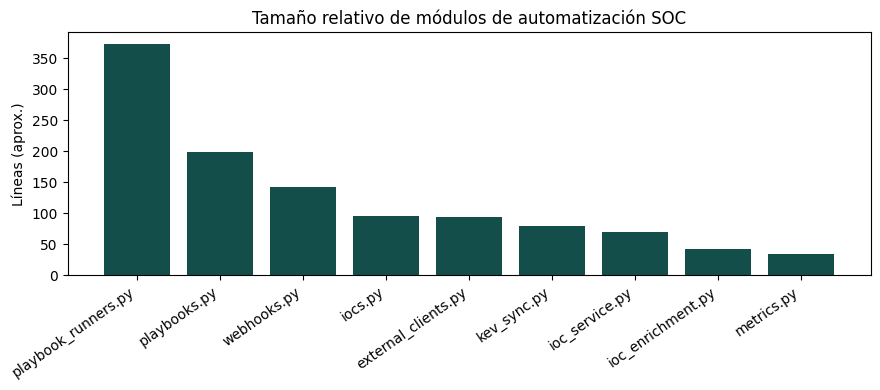

Total líneas (módulos listados): 1128


In [3]:
SERVICIOS = [
    "backend/app/services/ioc_enrichment.py",
    "backend/app/services/ioc_service.py",
    "backend/app/services/external_clients.py",
    "backend/app/services/playbook_runners.py",
    "backend/app/services/kev_sync.py",
    "backend/app/services/metrics.py",
    "backend/app/routes/webhooks.py",
    "backend/app/routes/playbooks.py",
    "backend/app/routes/iocs.py",
]

stats = []
for rel in SERVICIOS:
    path = ROOT / rel
    text = path.read_text(encoding="utf-8")
    lines = [ln for ln in text.splitlines() if ln.strip() and not ln.strip().startswith("#")]
    imports = [ln for ln in text.splitlines() if ln.strip().startswith(("import ", "from "))]
    stats.append({
        "módulo": path.name,
        "líneas_código": len(lines),
        "imports": len(imports),
        "ruta": rel,
    })

df_mod = pd.DataFrame(stats).sort_values("líneas_código", ascending=False)
display(df_mod)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_mod["módulo"], df_mod["líneas_código"], color="#134e4a")
ax.set_ylabel("Líneas (aprox.)")
ax.set_title("Tamaño relativo de módulos de automatización SOC")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print(f"Total líneas (módulos listados): {df_mod['líneas_código'].sum()}")

## 4. Flujo automatizado (resumen)

```
SIEM  --POST /api/webhooks/alert-->  webhooks.py  -->  Incident (BD)
Analista --POST /api/iocs/enrich-->  ioc_service.py  -->  veredicto / block
Admin --POST /api/playbooks/run-->  playbook_runners.py  -->  EDR/FW/AD (o simulado)
```

**Siguiente notebook:** `02_enriquecimiento_ioc.ipynb` — ejecuta y analiza el código de detección y scoring.